# D2C Customer Churn Capstone
## Part 1: Data Audit, EDA & Business Understanding

### Objective
This notebook performs:
- raw data inspection,
- schema understanding,
- data quality analysis,
- exploratory data analysis (EDA),
- churn-risk hypothesis generation,
- business interpretation for retention strategy.

Author: Prateek Parmar

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [39]:
# Dataset path

data_path = "../d2c churn data package/"

In [40]:
# Load datasets

customers = pd.read_csv(data_path + "customers.csv")
orders = pd.read_csv(data_path + "orders.csv")
support_tickets = pd.read_csv(data_path + "support_tickets.csv")
web_events = pd.read_csv(data_path + "web_events_snapshot.csv")
churn_labels = pd.read_csv(data_path + "churn_labels.csv")
intervention_history = pd.read_csv(data_path + "intervention_history.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


# Dataset Inspection

In [41]:
# Check dataset shapes

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support Tickets:", support_tickets.shape)
print("Web Events:", web_events.shape)
print("Churn Labels:", churn_labels.shape)
print("Intervention History:", intervention_history.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support Tickets: (1921, 8)
Web Events: (2400, 10)
Churn Labels: (2400, 4)
Intervention History: (2400, 5)


In [42]:
# Preview datasets

display(customers.head())
display(orders.head())
display(support_tickets.head())
display(web_events.head())
display(churn_labels.head())
display(intervention_history.head())

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [43]:
# Dataset information

customers.info()
orders.info()
support_tickets.info()
web_events.info()
churn_labels.info()
intervention_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  str    
 1   customer_id    10009 non-null  str    
 2   order_date     10009 non-null  str    
 3   category       1

# Missing Value Analysis

In [44]:
# Missing values check

missing_values = pd.DataFrame({
    "Missing Values": customers.isnull().sum(),
    "Percentage": (customers.isnull().sum() / len(customers)) * 100
})

missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
loyalty_tier,1386,57.750000
skin_type,401,16.708333
customer_id,0,0.000000
signup_date,0,0.000000
city_tier,0,0.000000
acquisition_channel,0,0.000000
age_group,0,0.000000
preferred_category,0,0.000000
marketing_consent,0,0.000000


In [45]:
# Missing values for all datasets

datasets = {
    "customers": customers,
    "orders": orders,
    "support_tickets": support_tickets,
    "web_events": web_events,
    "churn_labels": churn_labels,
    "intervention_history": intervention_history
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


CUSTOMERS
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

ORDERS
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

SUPPORT_TICKETS
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

WEB_EVENTS
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64

CHURN_LABELS
customer

# Duplicate Record Analysis

In [46]:
# Checking duplicate rows in all datasets

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

customers: 0 duplicate rows
orders: 0 duplicate rows
support_tickets: 0 duplicate rows
web_events: 0 duplicate rows
churn_labels: 0 duplicate rows
intervention_history: 0 duplicate rows


# Data Type Validation

In [47]:
# Convert date columns to datetime

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

print(customers.dtypes)
print("\n")
print(orders.dtypes)

customer_id                       str
signup_date            datetime64[us]
city_tier                         str
age_group                         str
acquisition_channel               str
loyalty_tier                      str
preferred_category                str
skin_type                         str
marketing_consent                 str
dtype: object


order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object


# Customer Distribution Analysis

In [48]:
# Customer distribution by city tier

customers['city_tier'].value_counts()

city_tier
Tier 1    1005
Tier 2     870
Tier 3     525
Name: count, dtype: int64

In [49]:
# Preferred category distribution

customers['preferred_category'].value_counts()


preferred_category
Skin Care    731
Hair Care    507
Baby Care    347
Makeup       326
Wellness     251
Fragrance    238
Name: count, dtype: int64

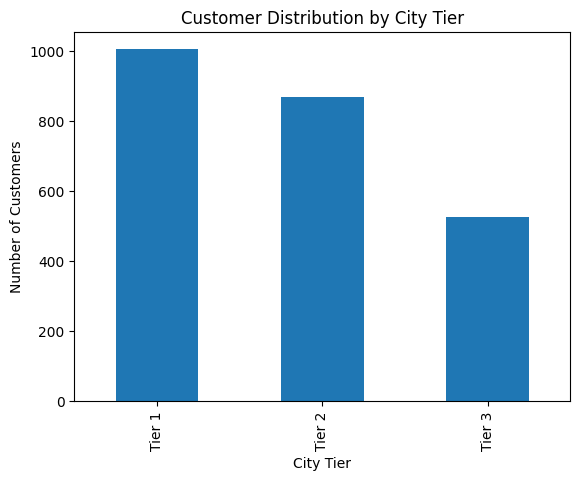

In [50]:
# City tier visualization

customers['city_tier'].value_counts().plot(kind='bar')

plt.title("Customer Distribution by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Number of Customers")

plt.show()

# Order & Revenue Analysis

In [51]:
# Total revenue

total_revenue = orders['gross_amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 7445680.13


In [52]:
# Average order value

average_order_value = orders['gross_amount'].mean()

print("Average Order Value:", average_order_value)

Average Order Value: 743.8985043460885


In [53]:
# Top selling categories

orders['category'].value_counts()

category
Skin Care    2700
Hair Care    2191
Makeup       1507
Baby Care    1438
Wellness     1096
Fragrance    1077
Name: count, dtype: int64

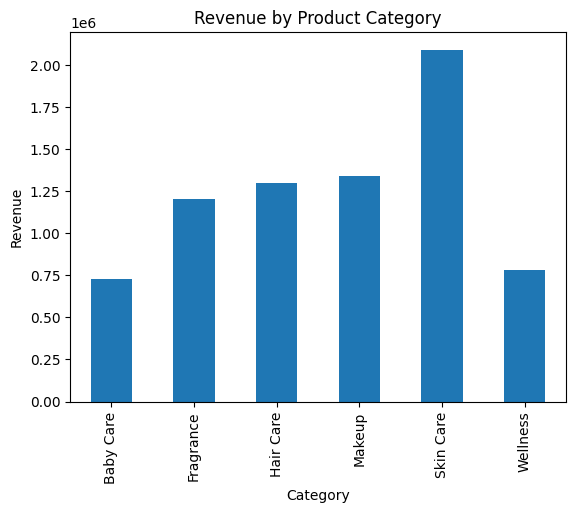

In [54]:
# Revenue by category

category_revenue = orders.groupby('category')['gross_amount'].sum()

category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

# Churn Analysis

In [55]:
# Churn distribution

churn_labels.columns

Index(['customer_id', 'snapshot_date', 'churn_next_60d', 'split'], dtype='str')

In [56]:
# Churn distribution

churn_labels['churn_next_60d'].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

In [57]:
# Churn percentage

churn_percentage = churn_labels['churn_next_60d'].value_counts(normalize=True) * 100

print(churn_percentage)

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


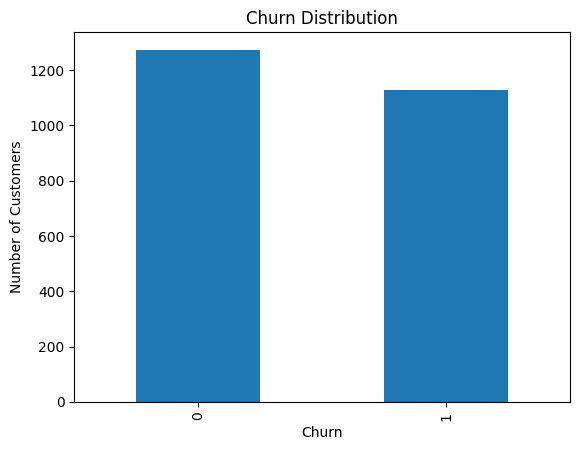

In [58]:
# Churn visualization

churn_labels['churn_next_60d'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# Customer-Level Data Merge

In [59]:
# Merge customer and churn data

customer_churn = customers.merge(
    churn_labels,
    on='customer_id',
    how='left'
)

customer_churn.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train


In [60]:
# Check merged dataset shape

customer_churn.shape

(2400, 12)

In [61]:
# Churn by city tier

customer_churn.groupby('city_tier')['churn_next_60d'].mean()

city_tier
Tier 1    0.473632
Tier 2    0.477011
Tier 3    0.449524
Name: churn_next_60d, dtype: float64

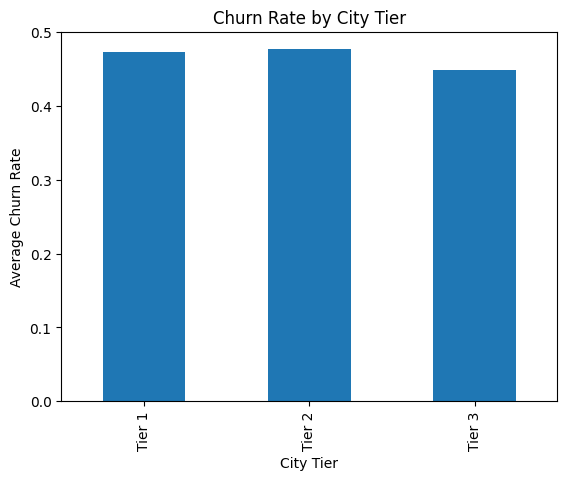

In [62]:
# Churn rate by city tier

customer_churn.groupby('city_tier')['churn_next_60d'].mean().plot(kind='bar')

plt.title("Churn Rate by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Average Churn Rate")

plt.show()

# Churn Analysis by Acquisition Channel

In [63]:
# Churn rate by acquisition channel

customer_churn.groupby('acquisition_channel')['churn_next_60d'].mean().sort_values(ascending=False)

acquisition_channel
Google Search    0.504292
Instagram        0.499033
Marketplace      0.491228
Influencer       0.476190
Referral         0.421717
Organic          0.398204
Name: churn_next_60d, dtype: float64

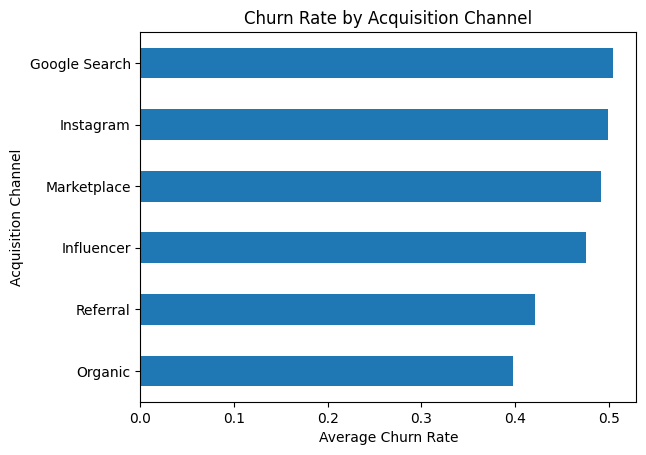

In [64]:
# Visualization

customer_churn.groupby('acquisition_channel')['churn_next_60d'].mean().sort_values().plot(kind='barh')

plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Average Churn Rate")
plt.ylabel("Acquisition Channel")

plt.show()

# Churn Analysis by Age Group

In [65]:
# Churn rate by age group

customer_churn.groupby('age_group')['churn_next_60d'].mean().sort_values(ascending=False)

age_group
35-44    0.483146
25-34    0.471770
45+      0.463602
18-24    0.455357
Name: churn_next_60d, dtype: float64

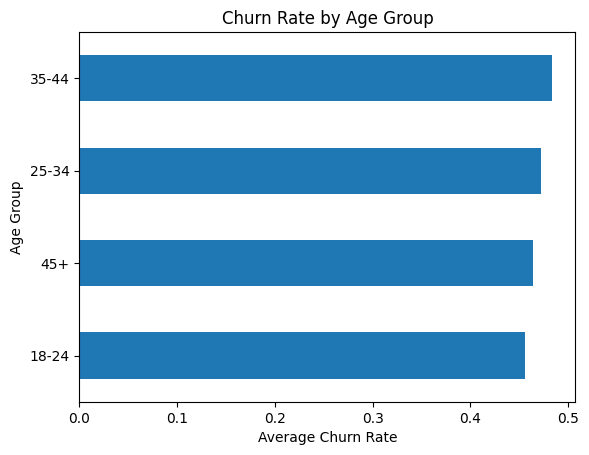

In [66]:
# Visualization

customer_churn.groupby('age_group')['churn_next_60d'].mean().sort_values().plot(kind='barh')

plt.title("Churn Rate by Age Group")
plt.xlabel("Average Churn Rate")
plt.ylabel("Age Group")

plt.show()

# Monthly Order Trend Analysis

In [67]:
# Extract month from order date

orders['order_month'] = orders['order_date'].dt.to_period('M')

monthly_orders = orders.groupby('order_month').size()

monthly_orders

order_month
2024-01     19
2024-02     44
2024-03    109
2024-04    132
2024-05    162
2024-06    203
2024-07    229
2024-08    263
2024-09    297
2024-10    372
2024-11    398
2024-12    456
2025-01    503
2025-02    507
2025-03    578
2025-04    594
2025-05    631
2025-06    527
2025-07    672
2025-08    669
2025-09    772
2025-10    990
2025-11    882
Freq: M, dtype: int64

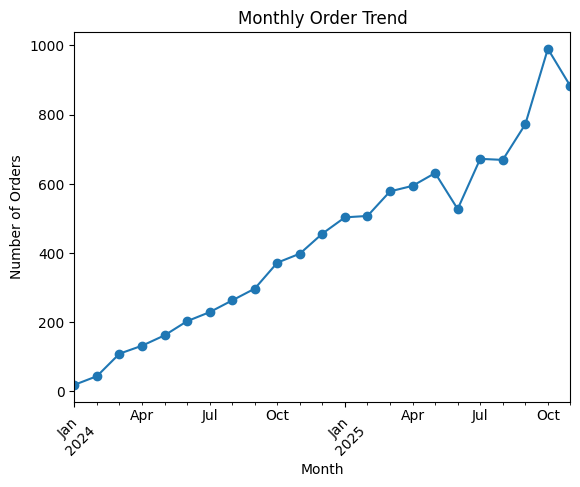

In [68]:
# Monthly order trend visualization

monthly_orders.plot(kind='line', marker='o')

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [69]:
# Monthly revenue trend

monthly_revenue = orders.groupby('order_month')['gross_amount'].sum()

monthly_revenue

order_month
2024-01     11405.15
2024-02     35149.17
2024-03     87411.08
2024-04     92043.86
2024-05    128909.38
2024-06    141201.04
2024-07    183872.28
2024-08    191534.88
2024-09    225810.29
2024-10    281448.94
2024-11    307665.55
2024-12    345847.17
2025-01    360382.26
2025-02    381837.57
2025-03    471376.69
2025-04    449981.25
2025-05    464104.53
2025-06    397457.46
2025-07    497103.15
2025-08    511550.72
2025-09    553081.33
2025-10    712687.22
2025-11    613819.16
Freq: M, Name: gross_amount, dtype: float64

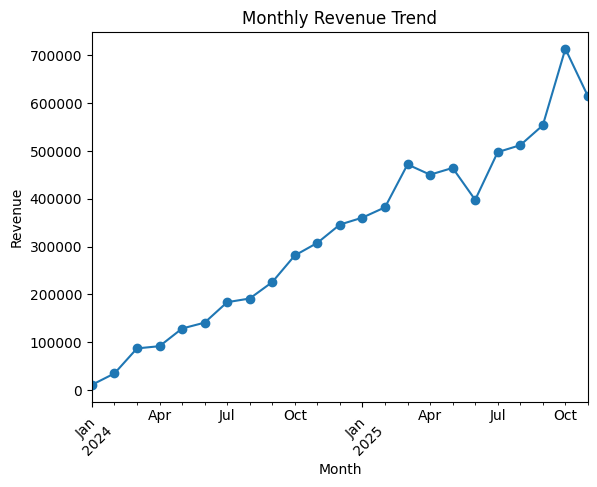

In [70]:
# Monthly revenue visualization

monthly_revenue.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Churn Analysis by Preferred Category

In [71]:
# Churn by preferred category

customer_churn.groupby('preferred_category')['churn_next_60d'].mean().sort_values(ascending=False)

preferred_category
Baby Care    0.507205
Wellness     0.482072
Skin Care    0.471956
Makeup       0.453988
Fragrance    0.453782
Hair Care    0.451677
Name: churn_next_60d, dtype: float64

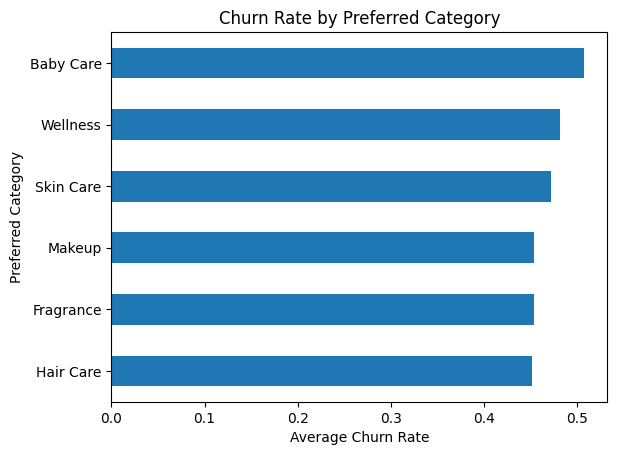

In [72]:
# Visualization

customer_churn.groupby('preferred_category')['churn_next_60d'].mean().sort_values().plot(kind='barh')

plt.title("Churn Rate by Preferred Category")
plt.xlabel("Average Churn Rate")
plt.ylabel("Preferred Category")

plt.show()

# Customer Signup Trend

In [73]:
# Monthly signup trend

customers['signup_month'] = customers['signup_date'].dt.to_period('M')

signup_trend = customers.groupby('signup_month').size()

signup_trend

signup_month
2024-01    116
2024-02    106
2024-03    120
2024-04    124
2024-05    117
2024-06    125
2024-07    121
2024-08    114
2024-09    111
2024-10    133
2024-11    127
2024-12    116
2025-01    127
2025-02    104
2025-03    112
2025-04    110
2025-05    114
2025-06    100
2025-07    116
2025-08    120
2025-09     67
Freq: M, dtype: int64

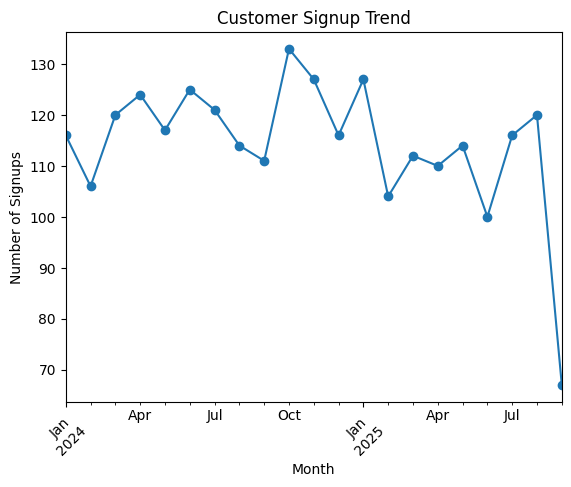

In [74]:
# Signup trend visualization

signup_trend.plot(kind='line', marker='o')

plt.title("Customer Signup Trend")
plt.xlabel("Month")
plt.ylabel("Number of Signups")

plt.xticks(rotation=45)

plt.show()

# Key Business Insights

## Customer Insights
- Tier 1 cities contribute the highest customer base.
- Skin Care is the most preferred category among customers.
- A significant number of customers have missing loyalty tier information.

## Revenue Insights
- Skin Care generates the highest overall revenue.
- Average order value is approximately ₹744.
- Wellness and Baby Care generate comparatively lower revenue.

## Churn Insights
- Overall churn rate is close to 47%.
- Customers acquired through Google Search and Instagram show higher churn rates.
- Organic and Referral channels have relatively lower churn rates.

## Business Risks
- High churn rate can reduce long-term profitability.
- Missing customer loyalty information may impact personalization strategies.
- Certain acquisition channels may be bringing lower-quality customers.

## Recommendations
- Improve retention campaigns for high churn channels.
- Strengthen loyalty programs for repeat customers.
- Focus marketing investments on lower churn acquisition channels.
- Increase engagement for high-value categories like Skin Care and Hair Care.

# Conclusion

This exploratory data analysis identified major customer behavior patterns, revenue drivers, and churn trends for the D2C business.

The analysis revealed that:
- Skin Care is the strongest-performing category.
- Tier 1 cities contribute the highest customer volume.
- Churn rate is relatively high and requires retention-focused interventions.
- Acquisition channels significantly impact churn behavior.

These insights can help improve marketing strategies, customer retention, and revenue optimization.